## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load Dataset

In [2]:
file_path = "/content/Indian Liver Patient Dataset (ILPD).csv"

df = pd.read_csv(file_path, header=None)

In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## Provide Column names

In [4]:
column_names = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
    "Result"   # 1 = Liver disease, 2 = No liver disease
]

df.columns = column_names

In [5]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## Boxplot plotting for each column

Here we can define
- Quartile 1 (25% values are below this range)
- Quartile 3 (75% values are below this range)
- Inter Quartile Range (In general 50% of the data lies within Q1 and Q3 [Q3-Q1])
- Median (50% of the data points are below this value)
- Outliers (The distinct points that are very much further from the main distribution)

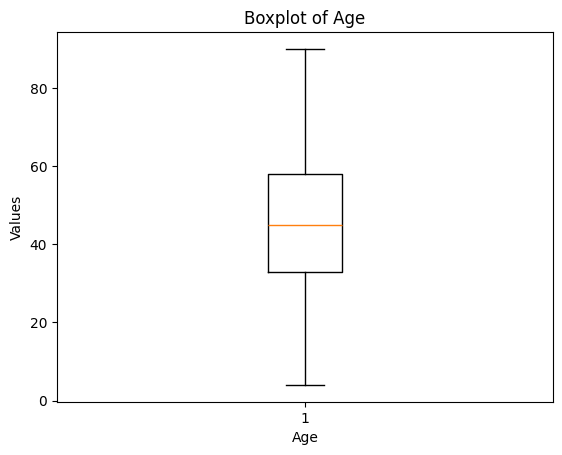

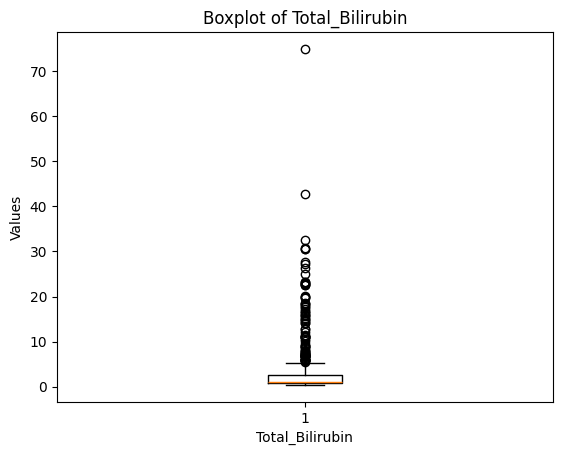

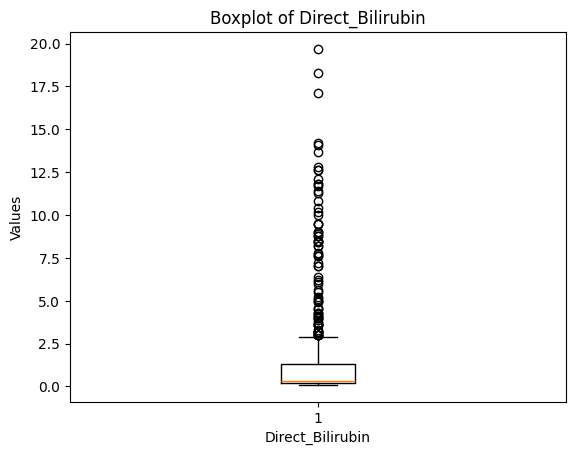

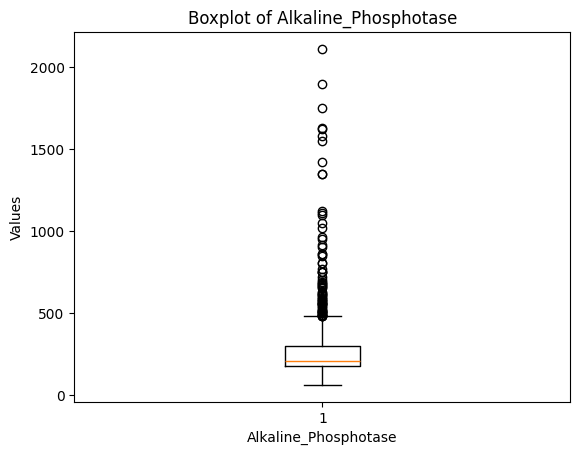

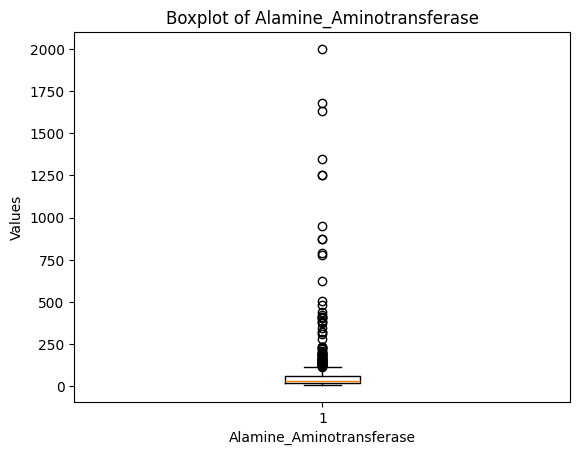

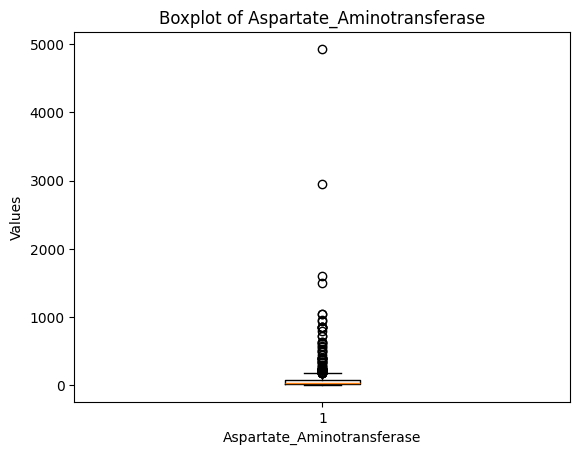

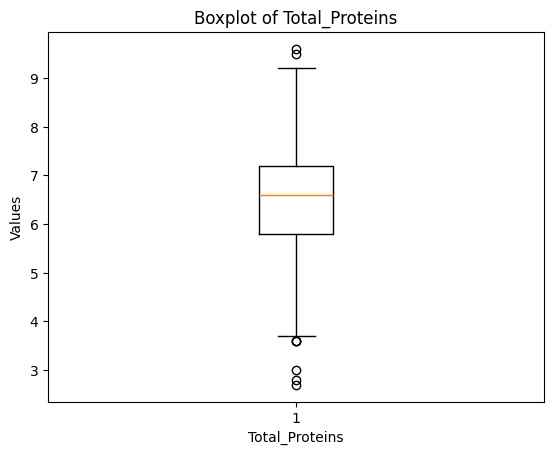

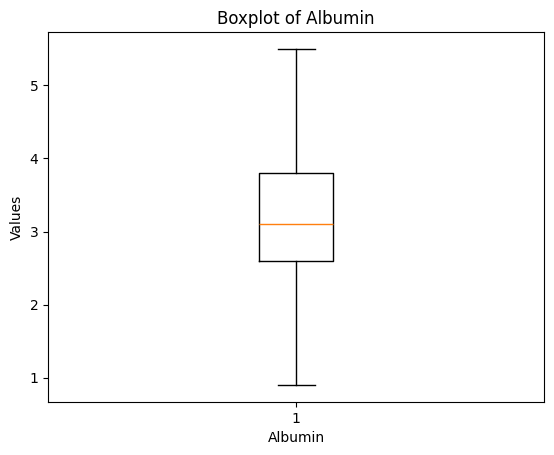

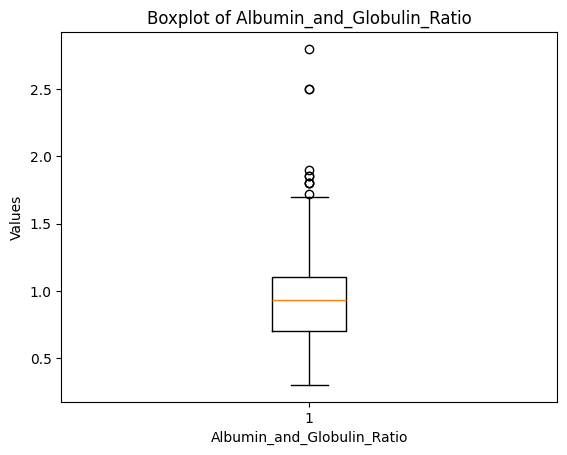

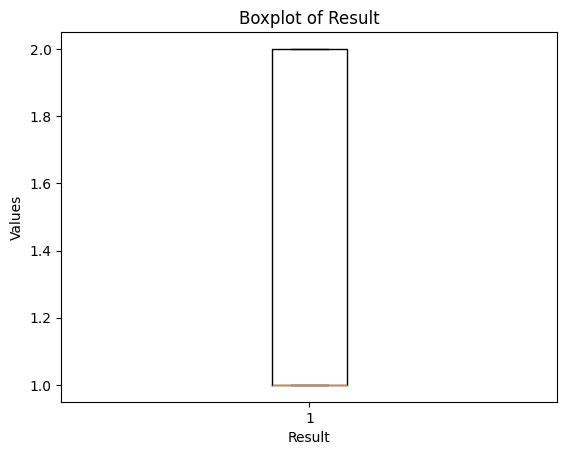

In [6]:
# Select only numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplot for each numeric column separately
for col in numeric_columns:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Values")
    plt.show()

## IQR values along with Q1 and Q3 values (IQR=Q3-Q1)

In [7]:
iqr_table = pd.DataFrame(columns=["Q1", "Q3", "IQR"])

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    iqr_table.loc[col] = [Q1, Q3, IQR]

print(iqr_table)

                               Q1     Q3    IQR
Age                          33.0   58.0   25.0
Total_Bilirubin               0.8    2.6    1.8
Direct_Bilirubin              0.2    1.3    1.1
Alkaline_Phosphotase        175.5  298.0  122.5
Alamine_Aminotransferase     23.0   60.5   37.5
Aspartate_Aminotransferase   25.0   87.0   62.0
Total_Proteins                5.8    7.2    1.4
Albumin                       2.6    3.8    1.2
Albumin_and_Globulin_Ratio    0.7    1.1    0.4
Result                        1.0    2.0    1.0


## Kurtosis value calculation along with histogram and density curve plotting

### Kurtosis Formula

Kurtosis measures how heavy the tails of a distribution are. (basically influence of outliers in the overall distribution)

$$
\text{Kurtosis} =
\frac{1}{N} \sum_{i=1}^{N}
\left(\frac{x_i - \mu}{\sigma}\right)^4
$$

Where:

- $x_i$ = Each data value  
- $\mu$ = Mean of the distribution  
- $\sigma$ = Standard deviation of the distribution
- $N$ = Number of observations  
- $\sum$ = Summation of values



Age Kurtosis (General): 2.43445217340719


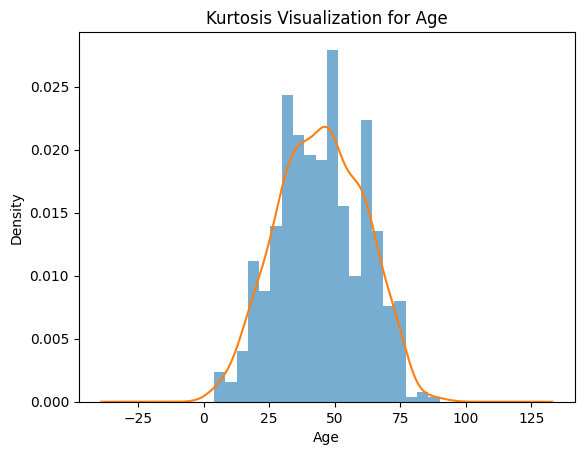

Total_Bilirubin Kurtosis (General): 39.8355530837899


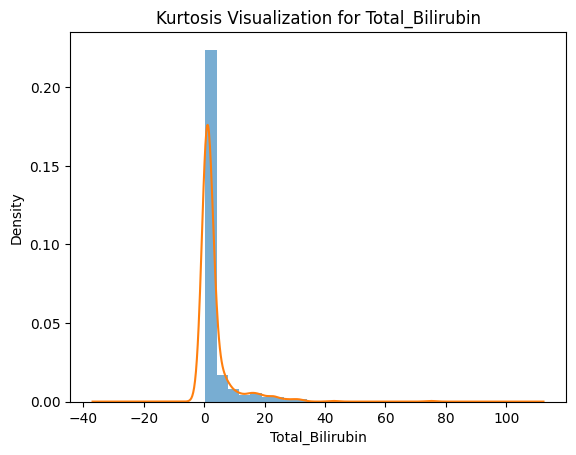

Direct_Bilirubin Kurtosis (General): 14.2451252850919


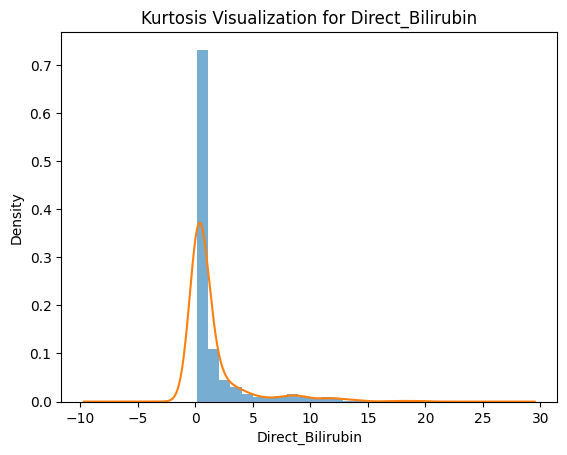

Alkaline_Phosphotase Kurtosis (General): 20.590665553363568


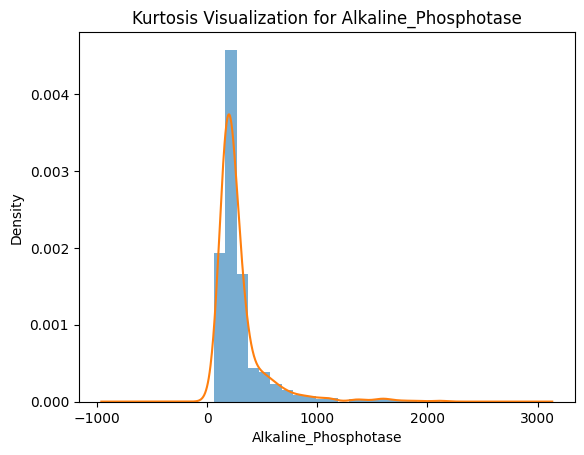

Alamine_Aminotransferase Kurtosis (General): 53.13643006330843


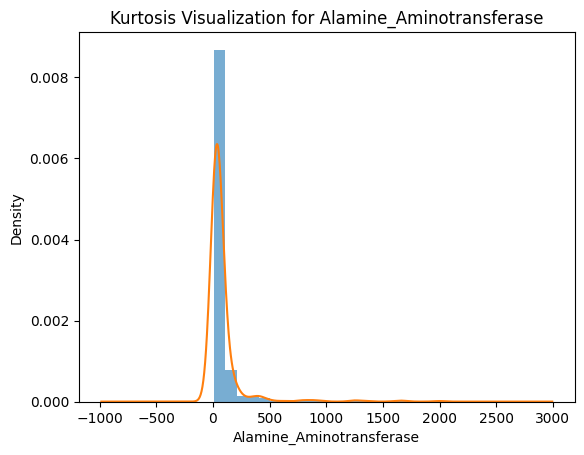

Aspartate_Aminotransferase Kurtosis (General): 152.61837543656333


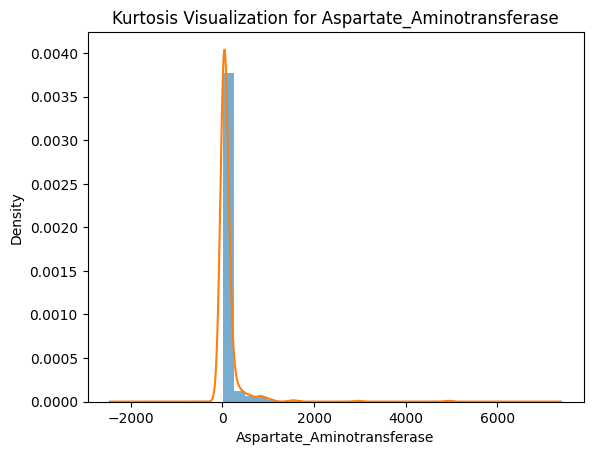

Total_Proteins Kurtosis (General): 3.220770790899148


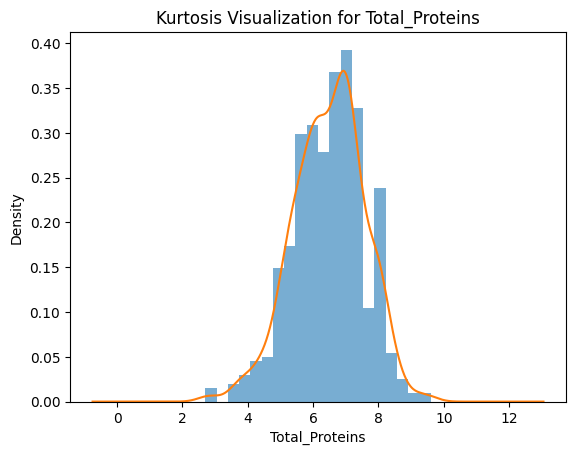

Albumin Kurtosis (General): 2.6051400404698524


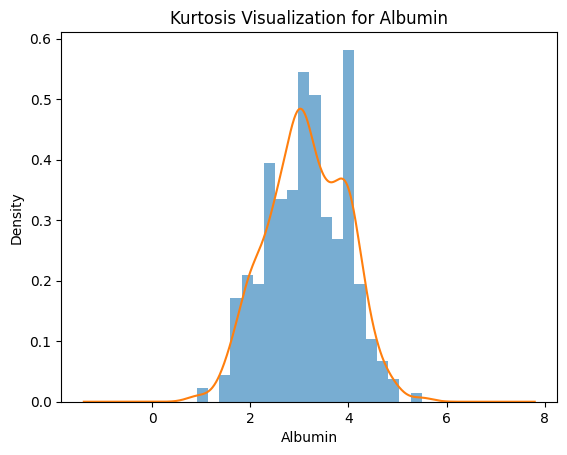

Albumin_and_Globulin_Ratio Kurtosis (General): 6.243282337387129


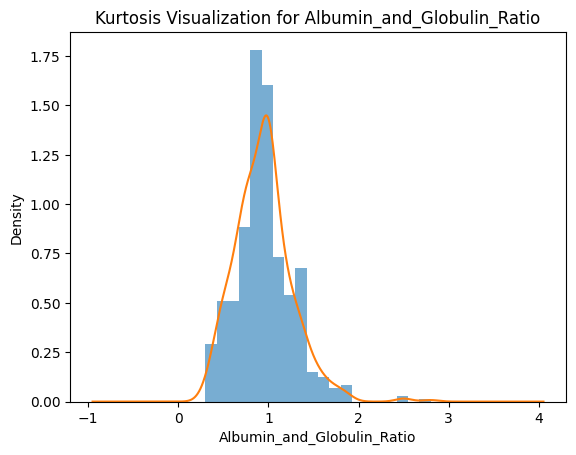

Result Kurtosis (General): 1.8924602717641361


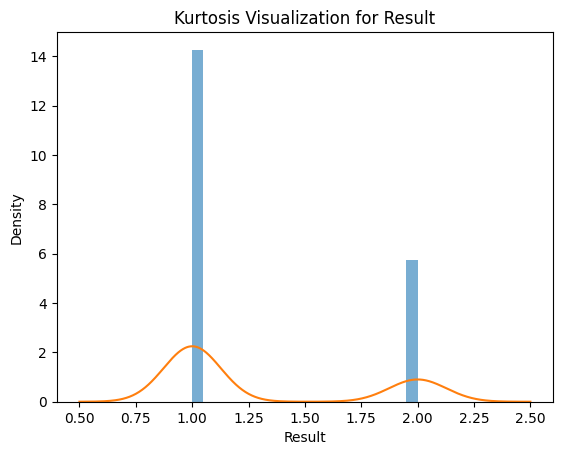

In [8]:
import numpy as np
import matplotlib.pyplot as plt

for col in numeric_columns:
    plt.figure()

    data = df[col].dropna()

    data.plot(
        kind='hist',
        bins=20,
        density=True,
        alpha=0.6
    )

    data.plot(kind='kde')

    # Manual General Kurtosis Calculation
    n = len(data)
    mean = np.mean(data)
    std = np.std(data)

    kurtosis = np.sum((data - mean)**4) / (n * (std**4))

    plt.title(f"Kurtosis Visualization for {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    print(f"{col} Kurtosis (General): {kurtosis}")

    plt.show()

## Mean median and mode calculation

In [9]:
mean_values = df[numeric_columns].mean()
median_values = df[numeric_columns].median()
mode_values = df[numeric_columns].mode().iloc[0]

In [10]:
stats_table = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values
})

print(stats_table)

                                  Mean  Median   Mode
Age                          44.746141   45.00   60.0
Total_Bilirubin               3.298799    1.00    0.8
Direct_Bilirubin              1.486106    0.30    0.2
Alkaline_Phosphotase        290.576329  208.00  198.0
Alamine_Aminotransferase     80.713551   35.00   25.0
Aspartate_Aminotransferase  109.910806   42.00   23.0
Total_Proteins                6.483190    6.60    7.0
Albumin                       3.141852    3.10    3.0
Albumin_and_Globulin_Ratio    0.947064    0.93    1.0
Result                        1.286449    1.00    1.0


## Skewness value calculation along with histogram and density curve plotting

### Skewness Formula

Skewness measures the asymmetry of the distribution.

$$
\text{Skewness} = \frac{1}{N} \sum_{i=1}^{N} \left(\frac{x_i - \mu}{\sigma}\right)^3
$$

Where:

- $x_i$ = Each data point in the distribution  
- $\mu$ = Mean of the distribution
- $\sigma$ = Standard deviation of the distribution  
- $N$ = Total number of observations  
- $\sum$ = Summation of all values from $i=1$ to $N$

Age Skewness: -0.029309653174828306


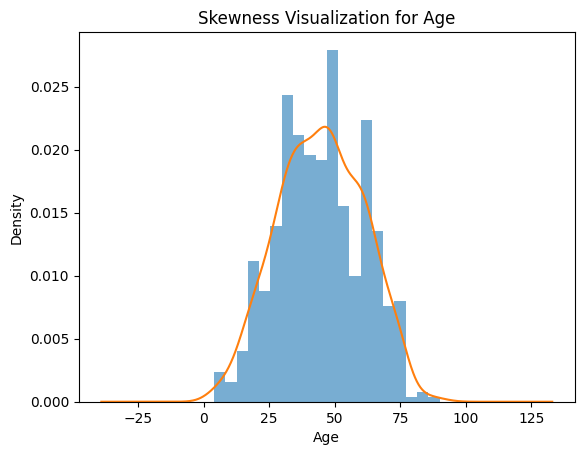

Total_Bilirubin Skewness: 4.894838524887895


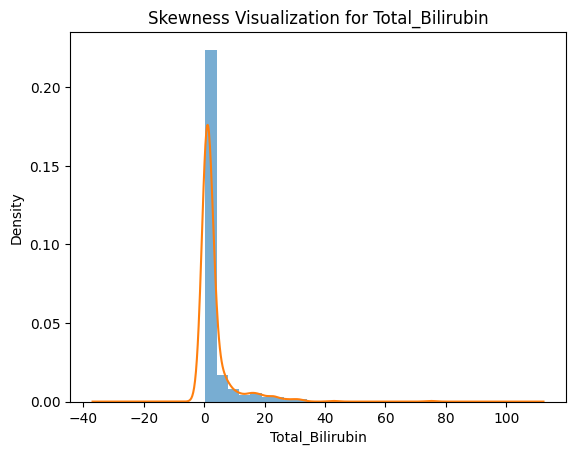

Direct_Bilirubin Skewness: 3.2041317604378063


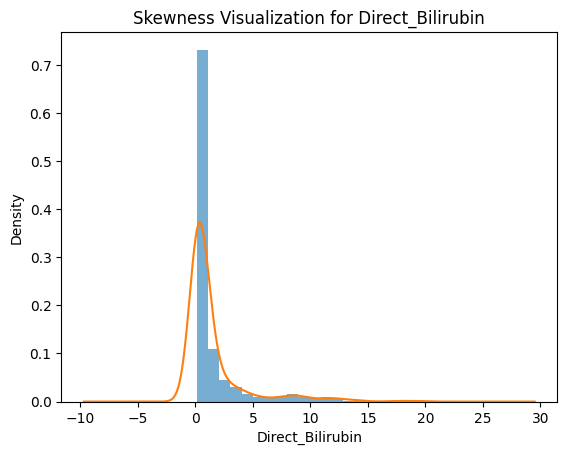

Alkaline_Phosphotase Skewness: 3.755412227842383


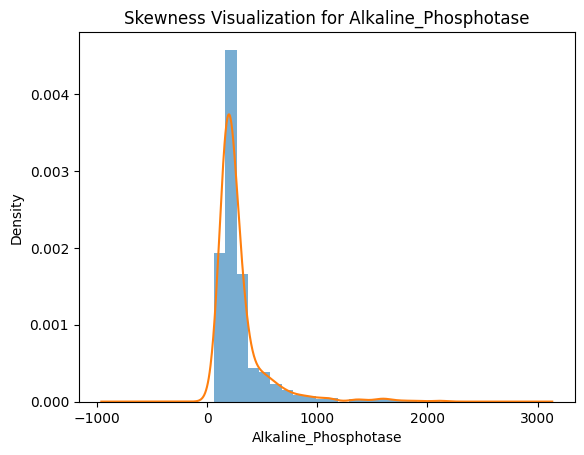

Alamine_Aminotransferase Skewness: 6.5323294640261365


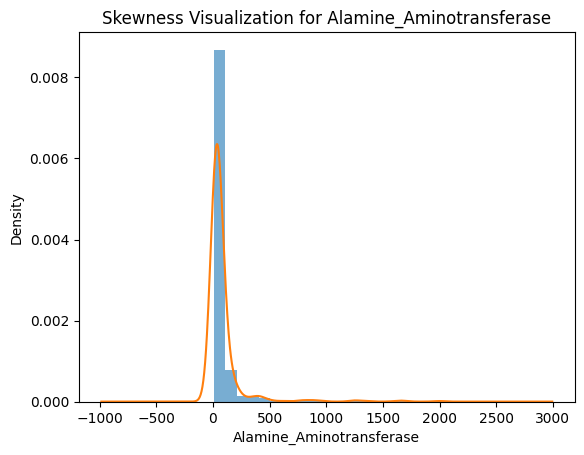

Aspartate_Aminotransferase Skewness: 10.519023554210737


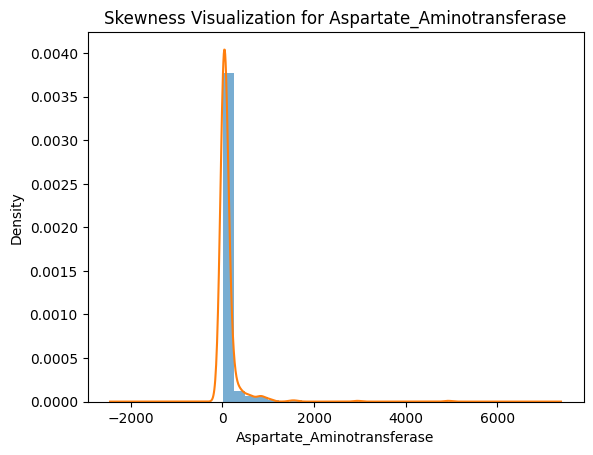

Total_Proteins Skewness: -0.2849366548744722


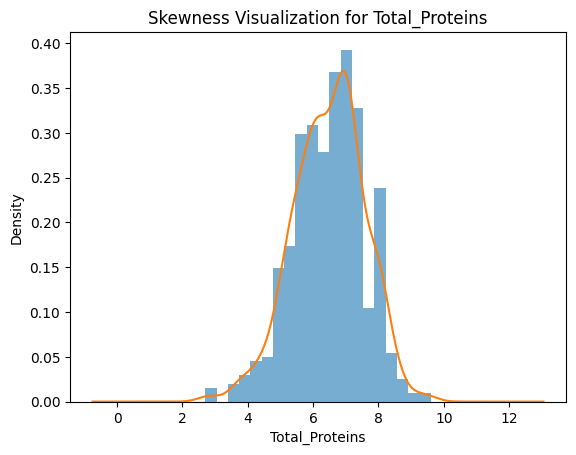

Albumin Skewness: -0.043572251735587784


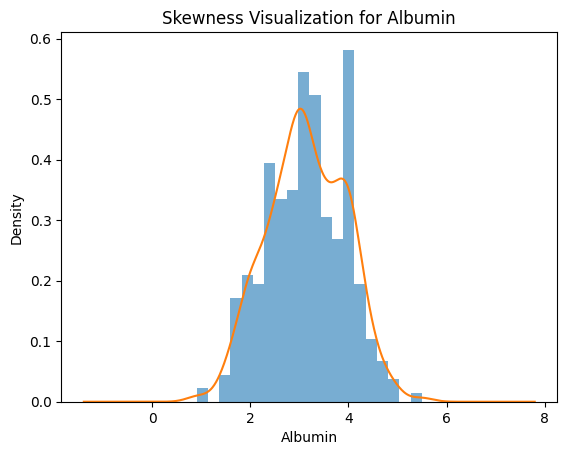

Albumin_and_Globulin_Ratio Skewness: 0.9897268717945911


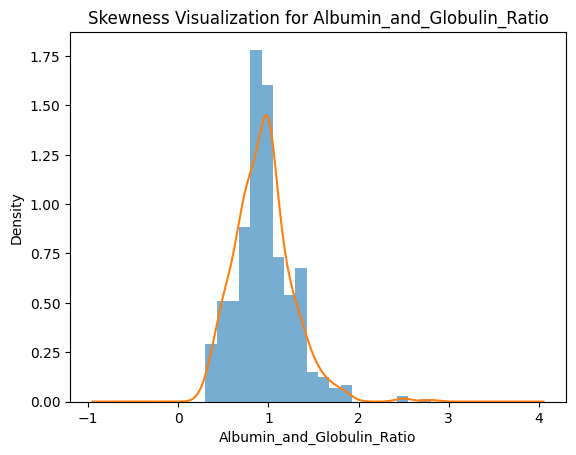

Result Skewness: 0.9447011547384413


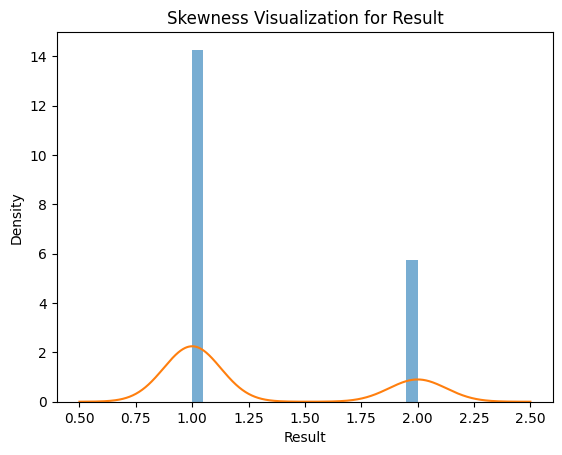

In [11]:
for col in numeric_columns:

    # Remove missing values
    data = df[col].dropna()

    # Number of samples
    n = len(data)

    # Mean
    mean = np.mean(data)

    # Standard deviation
    std = np.std(data)

    # Manual skewness calculation
    skewness = np.sum((data - mean)**3) / n
    skewness = skewness / (std**3)

    # Plot histogram + KDE
    plt.figure()

    data.plot(
        kind='hist',
        bins=20,
        density=True,
        alpha=0.6
    )

    data.plot(
        kind='kde'
    )

    plt.title(f"Skewness Visualization for {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    print(f"{col} Skewness:", skewness)

    plt.show()